# Solar PV Simulation Workflow
This example shows the different results of the different PV simulation workflows

Workflow:
1. Import required packages
2. Create locations DataFrame for single location
3. Run simulation for single location
4. Plot Capacity factor for single location
5. Computate single location, only using ERA5 weather data
6. Computate single location with Tracking
7. Simulate multiple locations

In [1]:
import reskit as rk
import pandas as pd

import matplotlib.pyplot as plt

%matplotlib inline

---
## Single Location based on Sarah and ERA5 Data.

In [14]:
# Make a dataframe for a single placement
placements = pd.DataFrame()
placements["lon"] = [
    6.083,
]  # Longitude
placements["lat"] = [
    50.775,
]  # Latitude
placements["tilt"] = [
    32,
]  # System tilt in degrees
placements["azimuth"] = [
    180,
]  # System azimuth in degrees
placements["capacity"] = [
    2000,
]  # Total system capacity in kW
placements["elev"] = [
    250,
]  # Altitude in meters

placements

,lon,lat,tilt,azimuth,capacity,elev
0,6.083,50.775,32,180,2000,250


In [15]:
out = rk.solar.openfield_pv_sarah_unvalidated(
    placements=placements,
    sarah_path=rk.TEST_DATA["sarah-like"],
    era5_path=rk.TEST_DATA["era5-like"],
    module="WINAICO WSx-240P6",  # PV module to use for simulation
)

print("Output is of type:", type(out))
print("Variables in output:")
for i, var in enumerate(list(out.variables)):
    print(" {i:2d}: {name:30s} - Dimensions:{dim}".format(i=i, name=var, dim=out[var].dims))

/fast/home/t-miosga/code/reskit/reskit/solar/workflows/solar_workflow_manager.py:970: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'N' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  module[param] = val_proj
/fast/home/t-miosga/code/reskit/reskit/weather/NCSource.py:258: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a si

Output is of type: <class 'xarray.core.dataset.Dataset'>
Variables in output:
  0: location                       - Dimensions:('location',)
  1: lon                            - Dimensions:('location',)
  2: lat                            - Dimensions:('location',)
  3: tilt                           - Dimensions:('location',)
  4: azimuth                        - Dimensions:('location',)
  5: capacity                       - Dimensions:('location',)
  6: elev                           - Dimensions:('location',)
  7: time                           - Dimensions:('time',)
  8: direct_normal_irradiance       - Dimensions:('time', 'location')
  9: global_horizontal_irradiance   - Dimensions:('time', 'location')
 10: surface_wind_speed             - Dimensions:('time', 'location')
 11: surface_pressure               - Dimensions:('time', 'location')
 12: surface_air_temperature        - Dimensions:('time', 'location')
 13: surface_dew_temperature        - Dimensions:('time', 'location')
 1

/fast/home/t-miosga/code/reskit/reskit/solar/workflows/solar_workflow_manager.py:970: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'N' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  module[param] = val_proj


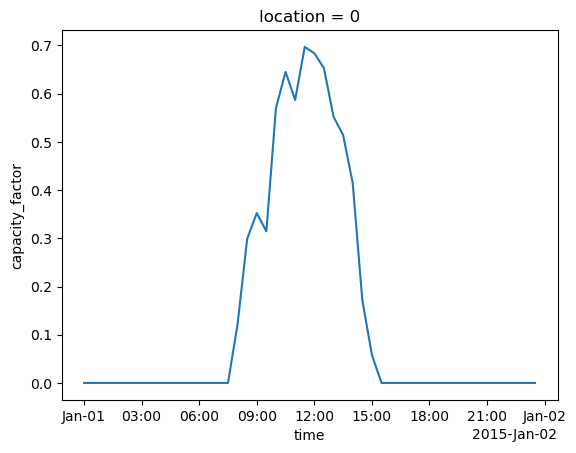

In [16]:
# Plot of the capacity factor time series for the single placement
out.capacity_factor.plot()

---
# Simulate single location, but only using ERA-5

In [ ]:
out = rk.solar.openfield_pv_era5(
    placements=placements,
    era5_path=rk.TEST_DATA["era5-like"],
    global_solar_atlas_ghi_path=rk.TEST_DATA["gsa-ghi-like.tif"],
    global_solar_atlas_dni_path=rk.TEST_DATA["gsa-dni-like.tif"],
    module="WINAICO WSx-240P6",  # PV module to use for simulation
)

print("Output is of type:", type(out))
print("Variables in output:")
for i, var in enumerate(list(out.variables)):
    print(" {i:2d}: {name:30s} - Dimensions:{dim}".format(i=i, name=var, dim=out[var].dims))

/fast/home/t-miosga/code/reskit/reskit/solar/workflows/solar_workflow_manager.py:970: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'N' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  module[param] = val_proj
/fast/home/t-miosga/code/reskit/reskit/weather/NCSource.py:258: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a si

Output is of type: <class 'xarray.core.dataset.Dataset'>
Variables in output:
  0: location                       - Dimensions:('location',)
  1: lon                            - Dimensions:('location',)
  2: lat                            - Dimensions:('location',)
  3: tilt                           - Dimensions:('location',)
  4: azimuth                        - Dimensions:('location',)
  5: capacity                       - Dimensions:('location',)
  6: elev                           - Dimensions:('location',)
  7: LRA_factor_global_horizontal_irradiance - Dimensions:('location',)
  8: LRA_factor_direct_normal_irradiance - Dimensions:('location',)
  9: time                           - Dimensions:('time',)
 10: global_horizontal_irradiance   - Dimensions:('time', 'location')
 11: direct_horizontal_irradiance   - Dimensions:('time', 'location')
 12: surface_wind_speed             - Dimensions:('time', 'location')
 13: surface_pressure               - Dimensions:('time', 'location')
 1

/fast/home/t-miosga/code/reskit/reskit/solar/workflows/solar_workflow_manager.py:970: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'N' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  module[param] = val_proj


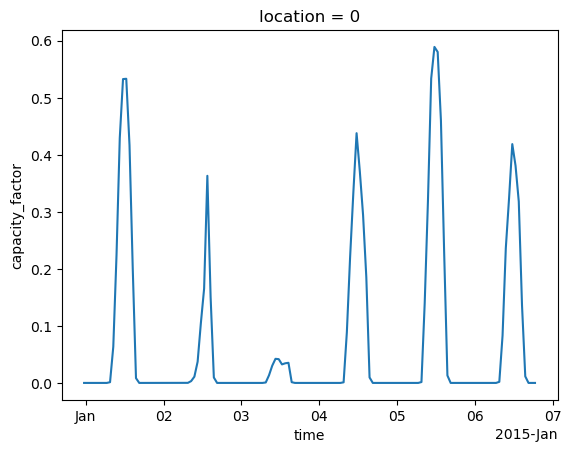

In [ ]:
out.capacity_factor.fillna(0).plot()

---
## Single Location with Tracking

In [9]:
out = rk.solar.openfield_pv_era5(
    placements=placements,
    era5_path=rk.TEST_DATA["era5-like"],
    global_solar_atlas_ghi_path=rk.TEST_DATA["gsa-ghi-like.tif"],
    global_solar_atlas_dni_path=rk.TEST_DATA["gsa-dni-like.tif"],
    module="WINAICO WSx-240P6",  # Module to use for simulation
    tracking="single_axis",
)

/fast/home/t-miosga/code/reskit/reskit/solar/workflows/solar_workflow_manager.py:970: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'N' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  module[param] = val_proj
/fast/home/t-miosga/code/reskit/reskit/weather/NCSource.py:258: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a si

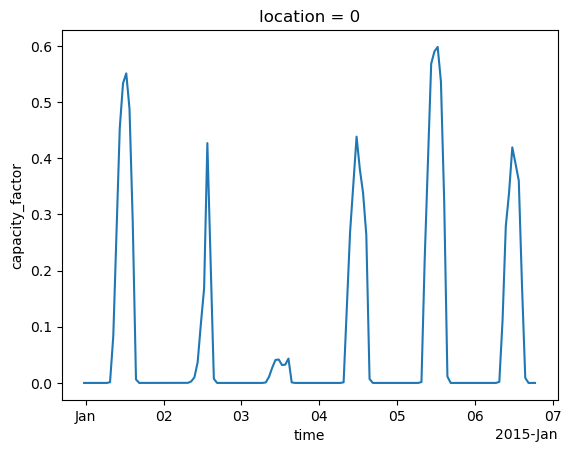

In [10]:
out.capacity_factor.fillna(0).plot()

---
## Simulating multiple locations is the same as simulating a single location
- It is recommended to simulate multiple locations at once!

In [ ]:
# Make a placements dataframe with multiple locations
placements = pd.DataFrame()
placements["lon"] = [
    6.083,
    6.090,
    6.095,
    6.100,
    6.105,
]  # Longitude
placements["lat"] = [
    50.775,
    50.780,
    50.785,
    50.790,
    50.795,
]  # Latitude
placements["tilt"] = [
    32,
    25,
    20,
    35,
    40,
]  # System tilt in degrees
placements["azimuth"] = [
    180,
    180,
    180,
    180,
    180,
]  # System azimuth in degrees
placements["capacity"] = [
    2000,
    2000,
    2000,
    2000,
    2000,
 ]  # Total system capacity in kW
placements["elev"] = [
    250,
    300,
    350,
    1000,
    -100,
] # Altitude in meters

placements

,lon,lat,tilt,azimuth,capacity,elev
0,6.083,50.775,32,180,2000,250
1,6.090,50.780,25,180,2000,300
2,6.095,50.785,20,180,2000,350
3,6.100,50.790,35,180,2000,1000
4,6.105,50.795,40,180,2000,-100


In [ ]:
# Run simulation with ERA5 workflow
out = rk.solar.openfield_pv_era5(
    placements=placements,
    era5_path=rk.TEST_DATA["era5-like"],
    global_solar_atlas_ghi_path=rk.TEST_DATA["gsa-ghi-like.tif"],
    global_solar_atlas_dni_path=rk.TEST_DATA["gsa-dni-like.tif"],
    module="WINAICO WSx-240P6",  # Module to use for simulation
)

/fast/home/t-miosga/code/reskit/reskit/solar/workflows/solar_workflow_manager.py:970: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'N' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  module[param] = val_proj
/fast/home/t-miosga/code/reskit/reskit/weather/NCSource.py:258: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a si

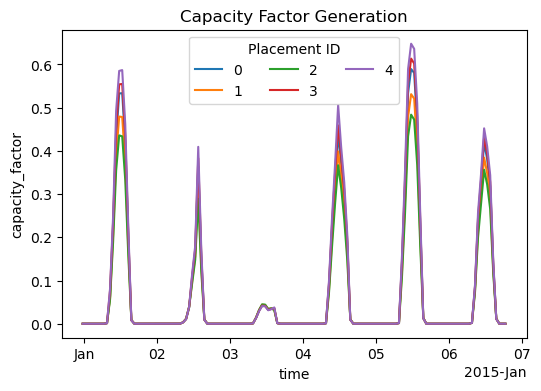

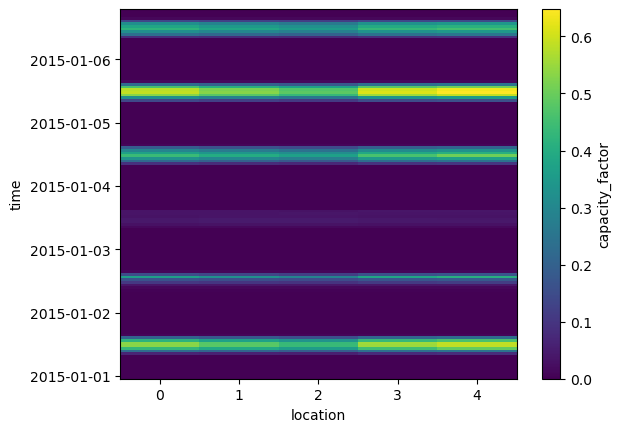

In [ ]:
# Same plot as in single examples, but now for multiple placements
plt.figure(figsize=(6, 4))
for i in range(placements.shape[0]):
    out.capacity_factor[:, i].fillna(0).plot(label=i)

plt.legend(ncol=3, title="Placement ID")
plt.title("Capacity Factor Generation")
plt.show()

# Same Plot function as in single examples
out.capacity_factor.fillna(0).plot()